In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["axes.grid"] = False
sc.settings.set_figure_params(dpi=80, dpi_save=180, vector_friendly=True, transparent=True) #for figures

In [2]:
#Read output H5AD from Step-4: panNEC_chain_integration_script_Step4_subclustering.py 
results= "./pNET_comparative_clustering/pNET_updated_annotations_180123.h5ad"
adata= sc.read_h5ad(results)

In [3]:
#Remove L12 givem ambiguous markers here: 
adata_sub= adata[adata.obs['res_1']!= '12']

In [4]:
#Change acinar-like NE to "amphicrine 01"
#Change GIPR+ EEC-like NE to EEC-like NE (as the whole population isn't GIPR+)
adata_sub.obs['cell_states'] = (adata_sub.obs["cell_type_semifinal_v4"].map(lambda x: {"Acinar_like_NET01": "Amphicrine01 NE",
    "Acinar_like_NET02": "Amphicrine01 NE", "BRCA1/FANCA_NETp": "BRCA1/FANCA NEp", 
    "BRCA1/FANCA_NETp (acinar like)": "BRCA1/FANCA NEp (amphicrine)", 
    "Exo_glandular_mixed01": "Amphicrine02 NE", "Exo_glandular_mixed02": "Amphicrine03 NE",
    "HSPpos_NET": "HSP+ NE", "GIPR+ EEC like": "GIPR-high EEC-like NE",
    "Smooth muscle like tumors (SMT)": "WNT-high EEC-like NE", 
    "Stromal2": "Stromal (mixed)"}.get(x, x)).astype("category"))


Trying to set attribute `.obs` of view, copying.


In [5]:
adata_sub.obs['Cell states']= adata_sub.obs['cell_states'].cat.reorder_categories(['Amphicrine01 NE', 'Amphicrine02 NE', 'Amphicrine03 NE',
                        'WNT-high EEC-like NE', 'BRCA1/FANCA NEp (amphicrine)', 'BRCA1/FANCA NEp', 'GIPR-high EEC-like NE','HSP+ NE',
                        'Stromal1', 'Stromal (mixed)', 'Lymphocytes (non-tumor)', 'Macrophages (non-tumor)'])

adata_sub.obs['Cell states'].cat.categories

Index(['Amphicrine01 NE', 'Amphicrine02 NE', 'Amphicrine03 NE',
       'WNT-high EEC-like NE', 'BRCA1/FANCA NEp (amphicrine)',
       'BRCA1/FANCA NEp', 'GIPR-high EEC-like NE', 'HSP+ NE', 'Stromal1',
       'Stromal (mixed)', 'Lymphocytes (non-tumor)',
       'Macrophages (non-tumor)'],
      dtype='object')

In [6]:
#Simplify a/c to Philipp:
adata_sub.obs['Cell states'] = (adata_sub.obs["Cell states"].map(lambda x: {"Amphicrine01 NE": "Amphicrine acinar01",
    "Amphicrine02 NE": "Amphicrine acinar02", "BRCA1/FANCA NEp": "Neuroendocrine proliferating", 
    "BRCA1/FANCA NEp (amphicrine)": "Amphicrine acinar proliferating", 
    "Amphicrine03 NE": "Amphicrine acinar03", "WNT-high EEC-like NE": "Neuroendocrine EEC-like01",
    "HSP+ NE": "Neuroendocrine HSP+", "GIPR-high EEC-like NE": "Neuroendocrine EEC-like02", 
    "Stromal1": "Neuroendocrine stromal-like", 
    "Stromal (mixed)": "Stroma (normal)", "Lymphocytes (non-tumor)": "Lymphocytes", 
    "Macrophages (non-tumor)": "Macrophages"}.get(x, x)).astype("category"))

adata_sub.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Neuroendocrine EEC-like01', 'Amphicrine acinar proliferating',
       'Neuroendocrine proliferating', 'Neuroendocrine EEC-like02',
       'Neuroendocrine HSP+', 'Neuroendocrine stromal-like', 'Stroma (normal)',
       'Lymphocytes', 'Macrophages'],
      dtype='object')

In [7]:
#Map patients: 
adata_sub.obs['PatientID'] = (adata_sub.obs["source_label"].map(lambda x: {"SP084_007": "P07",
    "SP084_018": "P018", "SP084_019": "P019", "SP084_021": "P021", "SP084_024": "P024 (acinar-like)"}.get(x, x)).astype("category"))

In [8]:
#adata_norm= adata_sub.raw.to_adata()
#sc.pp.normalize_total(adata_norm, target_sum=1e4)
#sc.pp.log1p(adata_norm)

In [9]:
adata_sub.uns['Cell states_colors']= ['#80aaff', '#a64dff', '#d9b3ff', '#4080bf', '#000066', '#00b3b3', 
                                     '#00e6e6', '#004d4d', '#4dffb8', '#00b386', '#ff0000', '#ff704d']

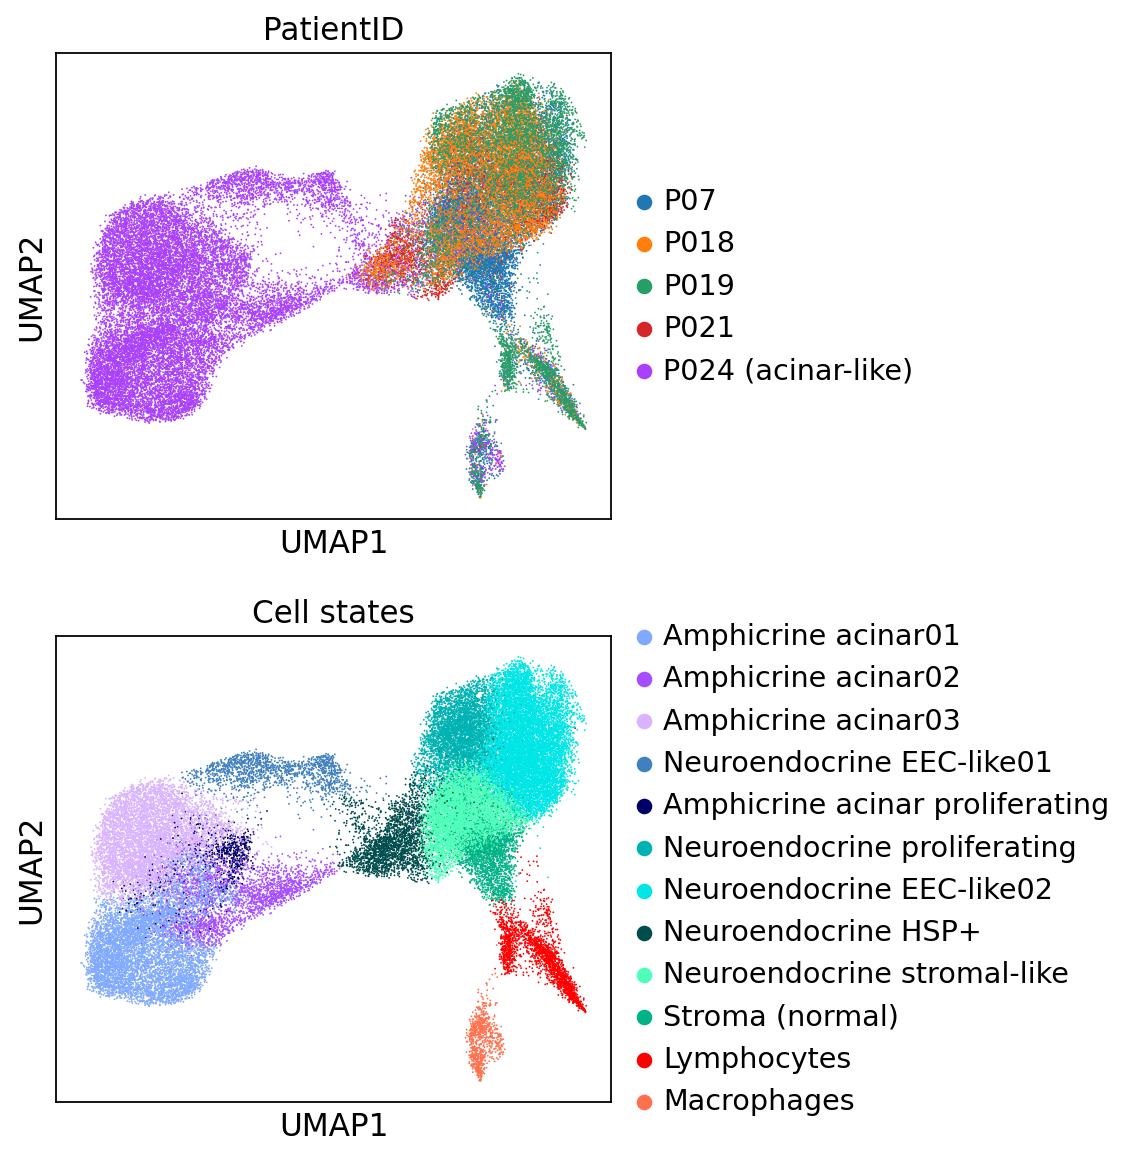

In [10]:
sc.pl.umap(adata_sub, color= ['PatientID', 'Cell states'], ncols=1)

In [11]:
adata_sub.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Neuroendocrine EEC-like01', 'Amphicrine acinar proliferating',
       'Neuroendocrine proliferating', 'Neuroendocrine EEC-like02',
       'Neuroendocrine HSP+', 'Neuroendocrine stromal-like', 'Stroma (normal)',
       'Lymphocytes', 'Macrophages'],
      dtype='object')

In [12]:
#Reorder the categories: 
adata_sub.obs['Cell states']= adata_sub.obs['Cell states'].cat.reorder_categories(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
                            'Amphicrine acinar proliferating', 'Neuroendocrine EEC-like01', 'Neuroendocrine EEC-like02', 
                            'Neuroendocrine proliferating', 'Neuroendocrine HSP+', 'Neuroendocrine stromal-like', 'Stroma (normal)',
                            'Lymphocytes', 'Macrophages'])

adata_sub.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Neuroendocrine EEC-like01',
       'Neuroendocrine EEC-like02', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+', 'Neuroendocrine stromal-like', 'Stroma (normal)',
       'Lymphocytes', 'Macrophages'],
      dtype='object')

In [13]:
#sc.pl.umap(adata_sub, color= ['Cell states'], ncols=1)

In [14]:
#Decrease the resolution of P24 populations: 
#adata_sub.uns['Cell states_colors']= ['#80aaff', '#a64dff', '#d9b3ff', '#4080bf', '#000066', '#00b3b3', 
                                     #'#00e6e6', '#004d4d', '#4dffb8', '#00b386', '#ff0000', '#ff704d']

#Change the normal stroma color in the cell states map:
adata_sub.uns['Cell states_colors']= ['#b3ccff', '#cc99ff', '#e6ccff', '#3973ac', '#9999ff',  
                                     '#00cccc', '#008080', '#004d4d', '#4dffb8', '#ff99cc', '#ff0000', '#ff704d']

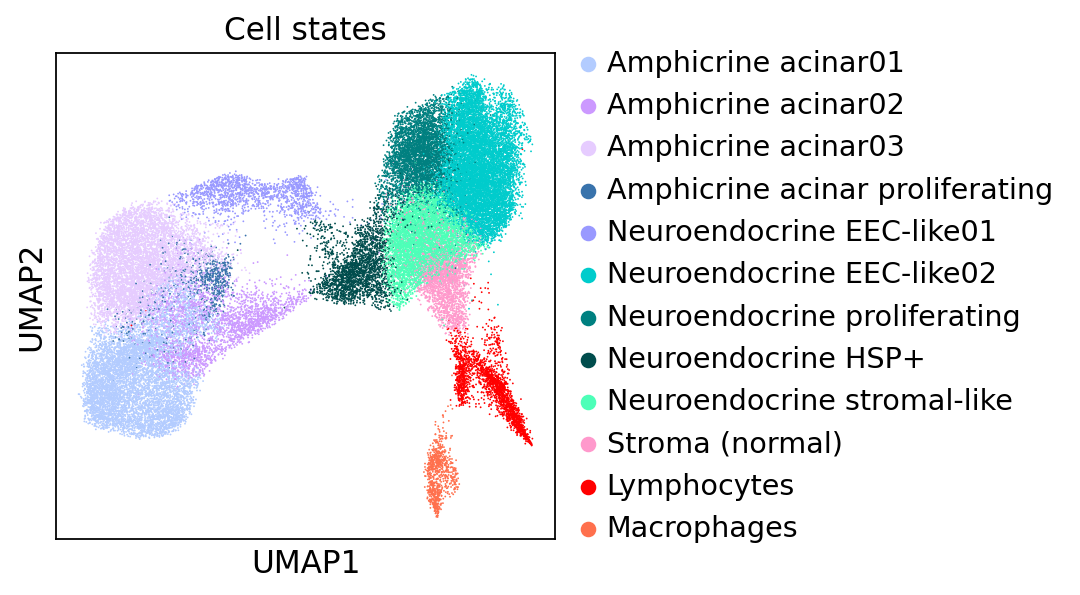

In [15]:
sc.pl.umap(adata_sub, color = ['Cell states'], save= "_Cell states_final_07082023.pdf")

In [16]:
#Main figure2B: Merge cell states to a coarse-grained broad level cell types:

#Stromal is called as "stromal-like NE" as these cells are classified as "aneuploid" from InferCNV analysis
#Main figure-1C. 
adata_sub.obs['cell_types'] = (adata_sub.obs["cell_type_semifinal_v4"].map(lambda x: {"Acinar_like_NET01": "NE (acinar)",
    "Acinar_like_NET02": "NE (acinar)", "BRCA1/FANCA_NETp": "NE", 
    "BRCA1/FANCA_NETp (acinar like)": "NE (acinar)", 
    "Exo_glandular_mixed01": "NE (acinar)", "Exo_glandular_mixed02": "NE (acinar)",
    "HSPpos_NET": "NE", "GIPR+ EEC like": "NE",
    "Smooth muscle like tumors (SMT)": "NE", 
    'Stromal1': 'Stromal-like NE', 'Stromal2': 'Stromal (mixed)', 
    "Lymphocytes (non-tumor)": "Immune (non-tumor)", 
    "Macrophages (non-tumor)": "Immune (non-tumor)"}.get(x, x)).astype("category"))

adata_sub.obs['Cell types']= adata_sub.obs['cell_types']
adata_sub.obs['Cell types'].cat.categories

Index(['Immune (non-tumor)', 'NE', 'NE (acinar)', 'Stromal (mixed)',
       'Stromal-like NE'],
      dtype='object')

In [17]:
#Philipp: I personally would drop Stromal-like NE from the main classes at treat it as NE (but others may say that the NE profile is not strong enough to do so)
adata_sub.obs['Cell types']= (adata_sub.obs["cell_types"].map(lambda x: {"NE": "Neuroendocrine",
            "NE (acinar)": "Amphicrine acinar", "Stromal-like NE": "Neuroendocrine", "Stromal (mixed)": "Stroma (normal)", 
            "Immune (non-tumor)": "Immune"}.get(x, x)).astype("category"))

adata_sub.obs['Cell types']= adata_sub.obs['Cell types'].cat.reorder_categories(['Neuroendocrine', 'Amphicrine acinar', 
                                                                                'Stroma (normal)', 'Immune'])
adata_sub.obs['Cell types'].cat.categories

Index(['Neuroendocrine', 'Amphicrine acinar', 'Stroma (normal)', 'Immune'], dtype='object')

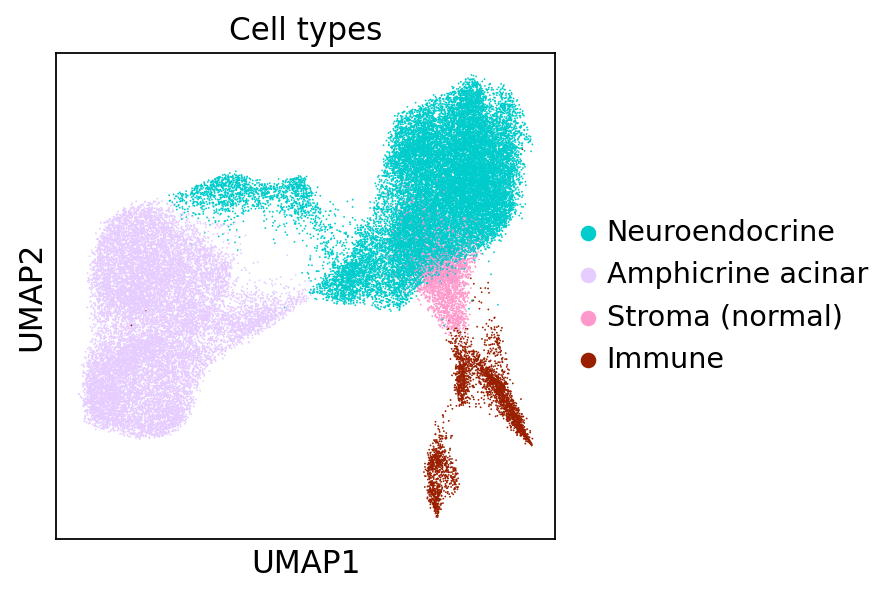

In [18]:
adata_sub.uns['Cell types_colors']= ['#00cccc', '#e6ccff', '#ff99cc','#991f00']

#Bertram asked to assign a different color code to "stroma": figure2B. 
sc.pl.umap(adata_sub, color = ['Cell types'], save= "_celltypes_final_11072023.pdf")

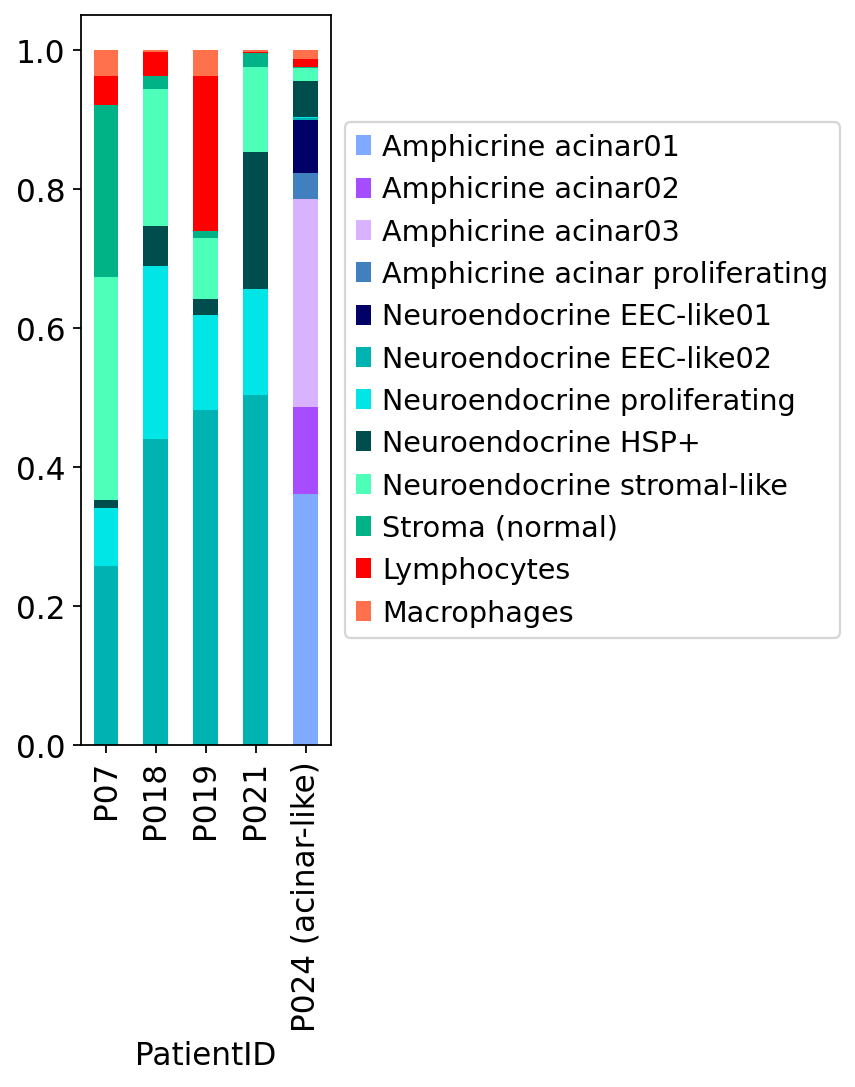

In [19]:
#Cell-state level: 
df= pd.crosstab(adata_sub.obs['PatientID'], adata_sub.obs['Cell states'], normalize= "index")

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (2,6)

pl = df.plot(kind="bar", stacked=True, rot=90, color= ['#80aaff', '#a64dff', '#d9b3ff', '#4080bf', '#000066', '#00b3b3', 
                                     '#00e6e6', '#004d4d', '#4dffb8', '#00b386', '#ff0000', '#ff704d'])
pl.grid(False)
pl.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('Cell_states_composition_v1_ExtdFig2C.pdf')

In [20]:
#!mkdir pnec_anndata_082023

In [21]:
results= "./pnec_anndata_082023/pNEC_updated_annot_07082023.h5ad"
adata_sub.write(results)

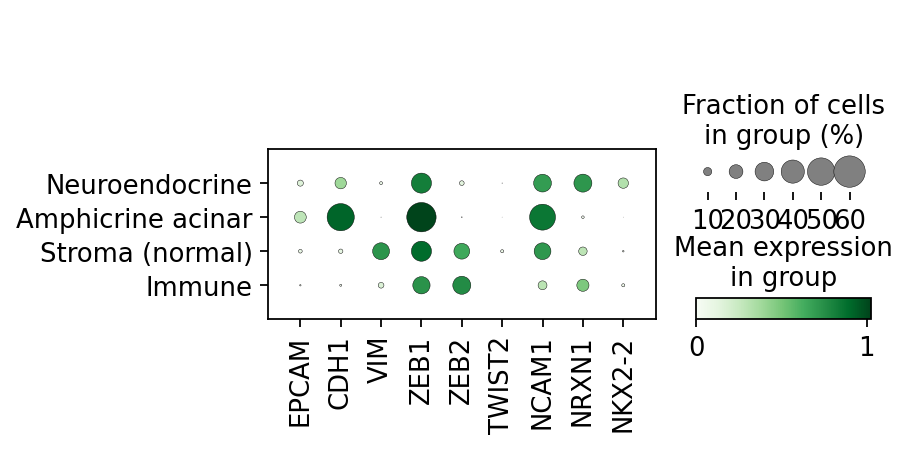

In [23]:
#Plot epithelial/mesenchymal markers with NE on a broader "cell type" level:
#NCAM1 is both a mesenchymal plus NE-associated gene. ZEB1 too?! @Katharina. 
sc.pl.dotplot(adata_norm,  ['EPCAM', 'CDH1', 'VIM', 'ZEB1', 'ZEB2', 'TWIST2', 'NCAM1', 'NRXN1', 'NKX2-2'], 
                groupby= 'Cell types', 
                swap_axes=False, dendrogram=False, 
                cmap= "Greens")

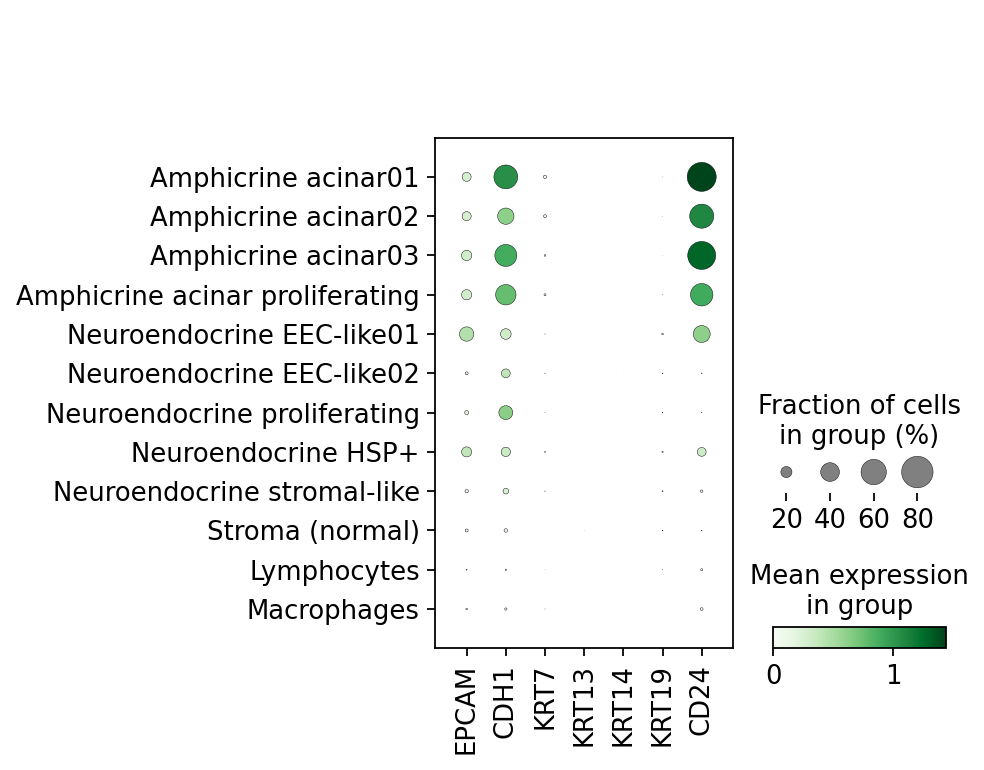

In [24]:
#Plot epithelial markers on a "cell state" level:
#KRTs/cytokeratins are not expressed. 
sc.pl.dotplot(adata_norm,  ['EPCAM', 'CDH1', 'KRT7', 'KRT13', 'KRT14', 'KRT19', 'CD24'], 
                groupby= 'Cell states', 
                swap_axes=False, dendrogram=False, 
                cmap= "Greens")

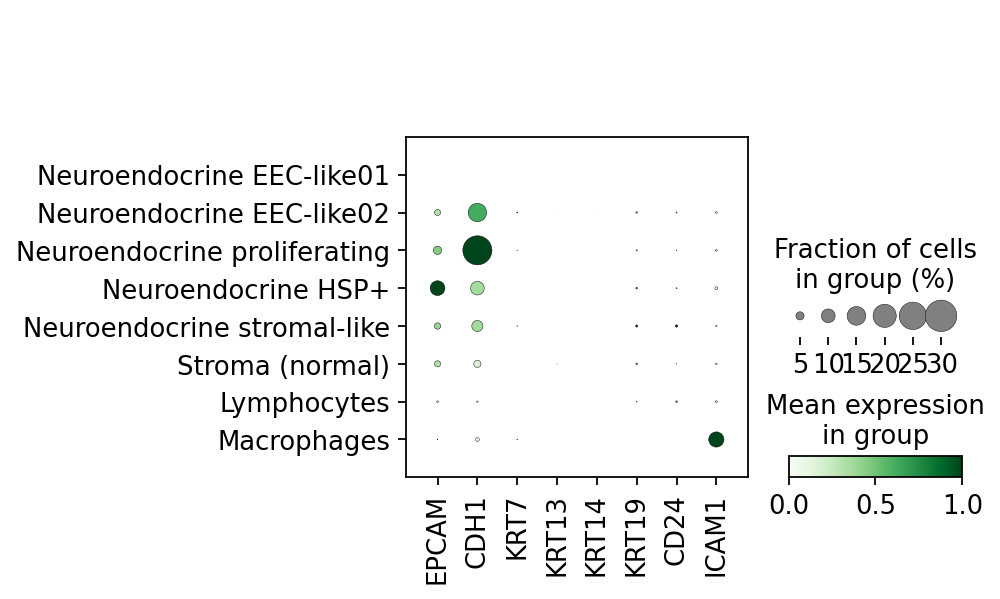

In [25]:
#Plot by removing P024:
sc.pl.dotplot(adata_norm[adata_norm.obs['PatientID']!= 'P024 (acinar-like)'], 
              ['EPCAM', 'CDH1', 'KRT7', 'KRT13', 'KRT14', 'KRT19', 'CD24', 'ICAM1'], 
                groupby= 'Cell states', 
              swap_axes=False, dendrogram=False, cmap= "Greens", standard_scale= "var")

P07


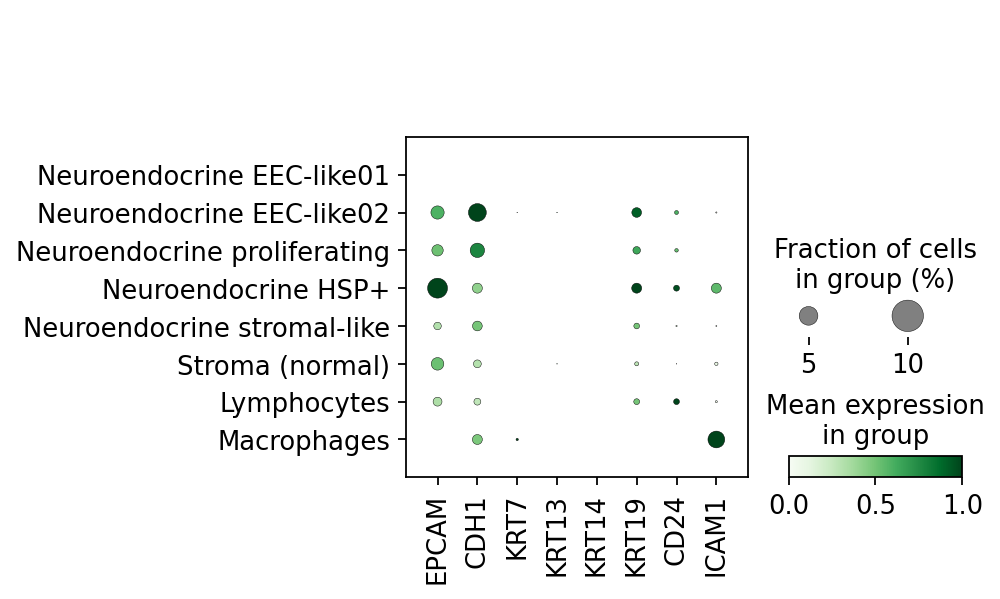

P018


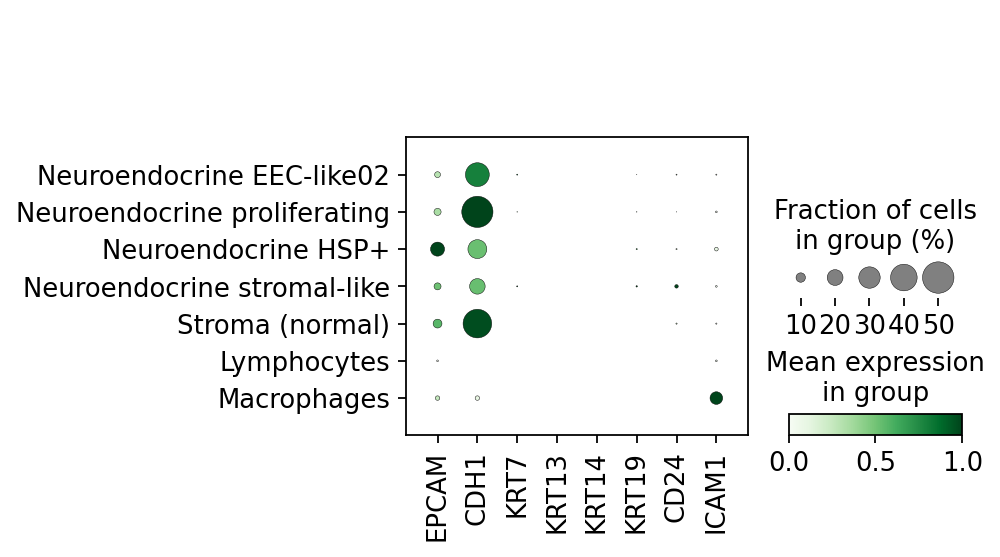

P019


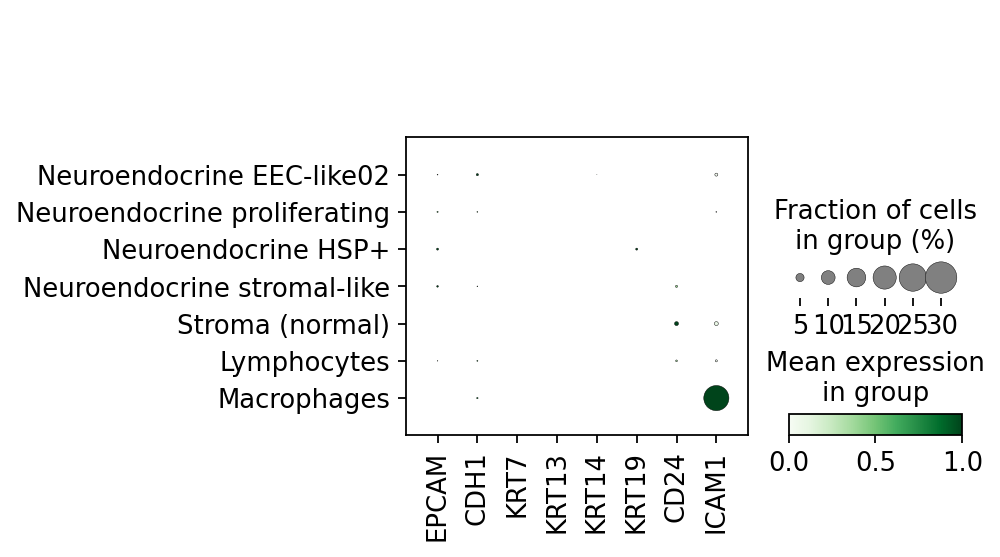

P021


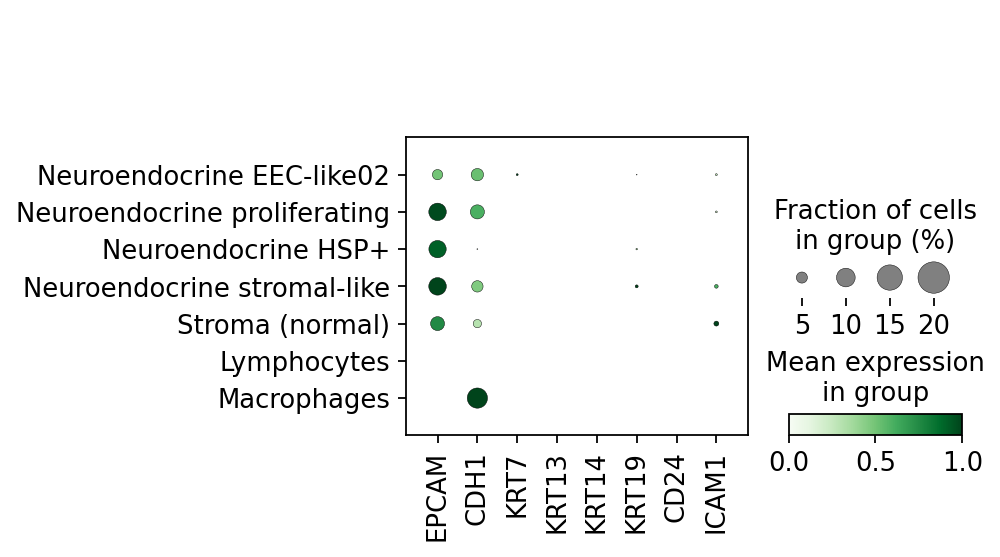

P024 (acinar-like)


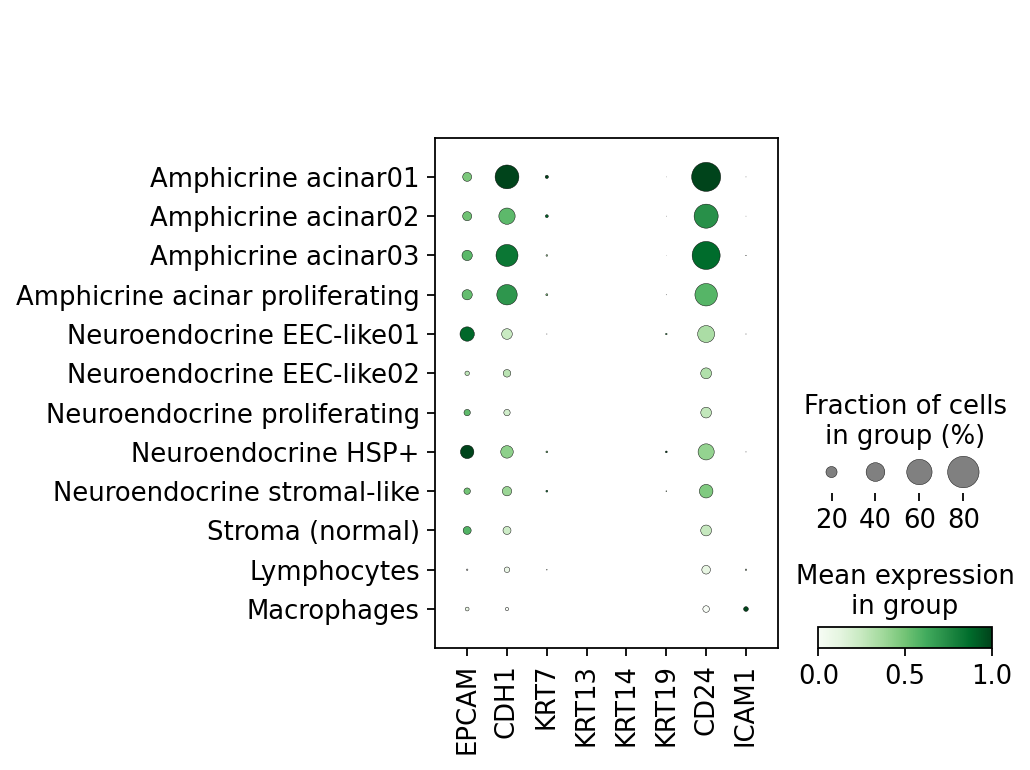

In [26]:
#Split the epithelial genes by patient identity: 
#Variable levels within the patient. 
for i in adata_norm.obs['PatientID'].cat.categories:
    print(i) 
    sc.pl.dotplot(adata_norm[adata_norm.obs['PatientID'] == i], ['EPCAM', 'CDH1', 'KRT7', 'KRT13', 'KRT14', 'KRT19', 'CD24', 'ICAM1'], 
                groupby= 'Cell states', 
              swap_axes=False, dendrogram=False, 
             cmap= "Greens", standard_scale= "var")

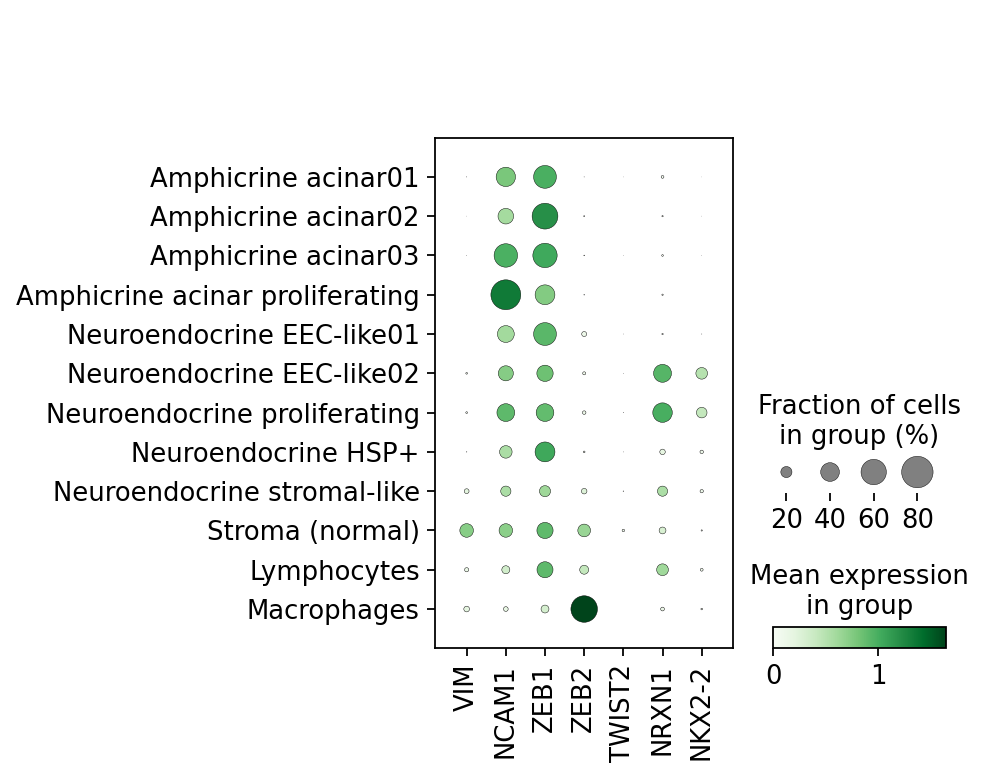

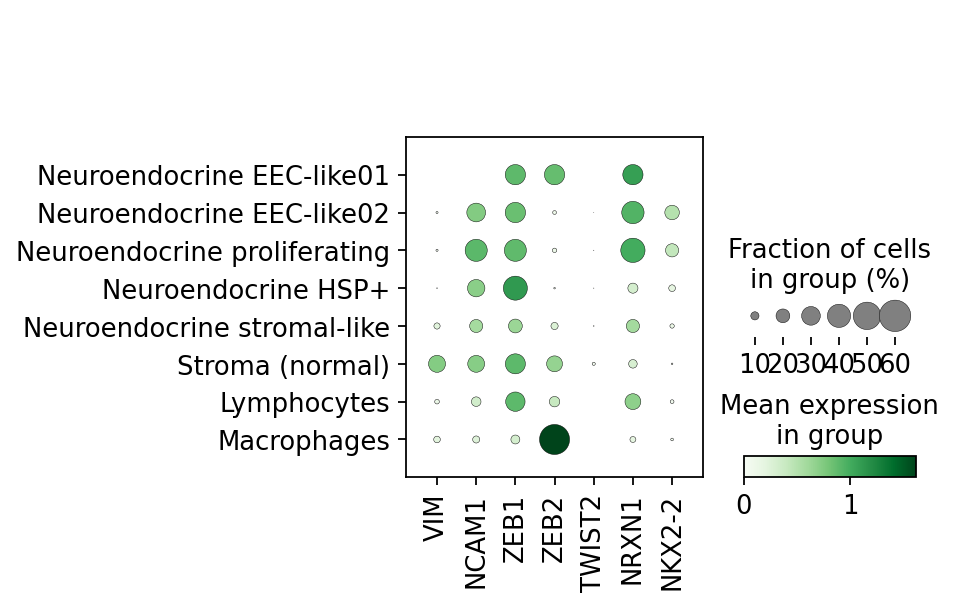

In [27]:
#Plot mesenchymal markers with NE:
#NCAM1, NRXN1 & NKX2-2 are expressed in NE cells. 
sc.pl.dotplot(adata_norm,  ['VIM', 'NCAM1', 'ZEB1', 'ZEB2', 'TWIST2', 'NRXN1', 'NKX2-2'], 
                groupby= 'Cell states', swap_axes=False, dendrogram=False, cmap= "Greens")


#Exclude P024 groups: 
sc.pl.dotplot(adata_norm[adata_norm.obs['PatientID']!= 'P024 (acinar-like)'],  
              ['VIM', 'NCAM1', 'ZEB1', 'ZEB2', 'TWIST2', 'NRXN1', 'NKX2-2'], 
                groupby= 'Cell states', swap_axes=False, dendrogram=False, cmap= "Greens")

P07


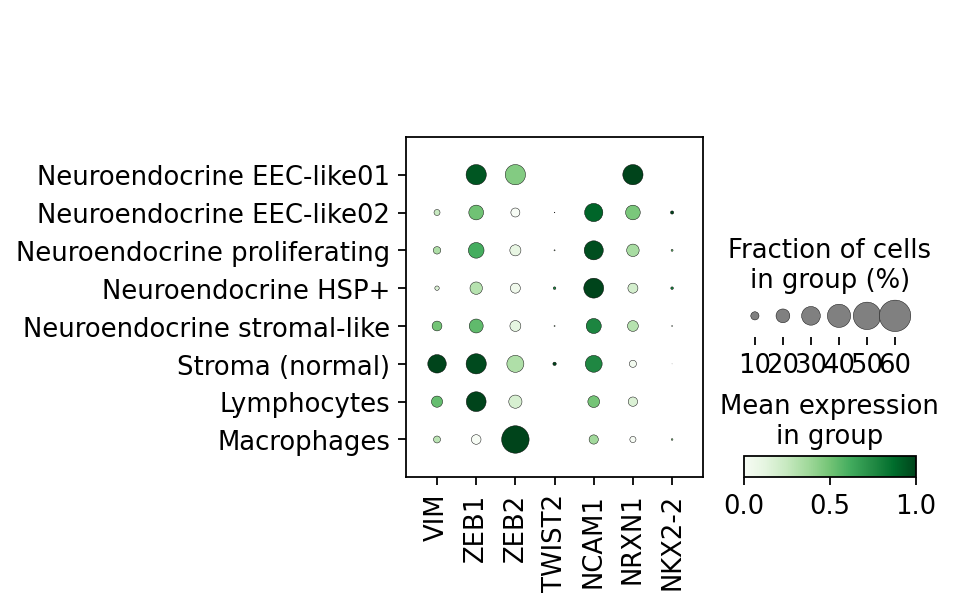

P018


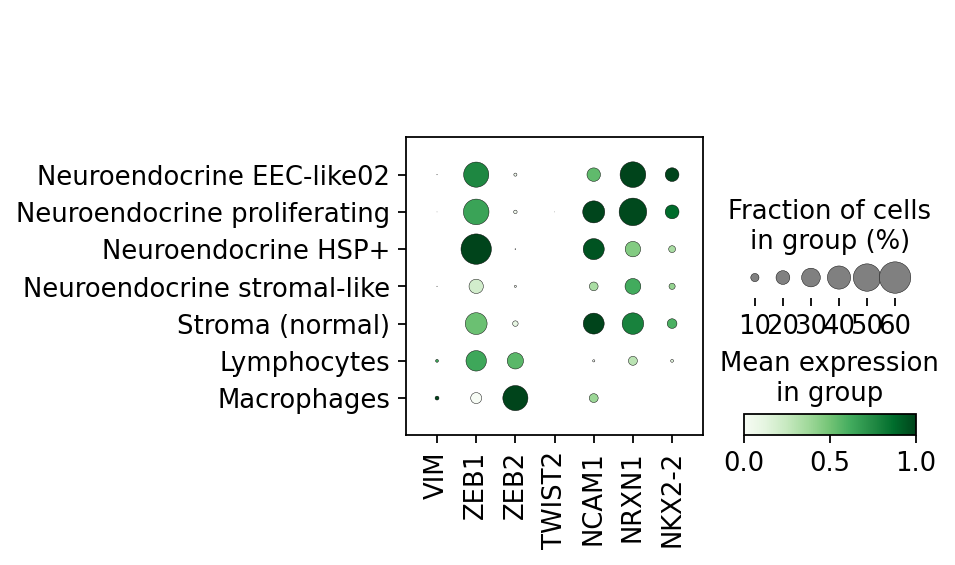

P019


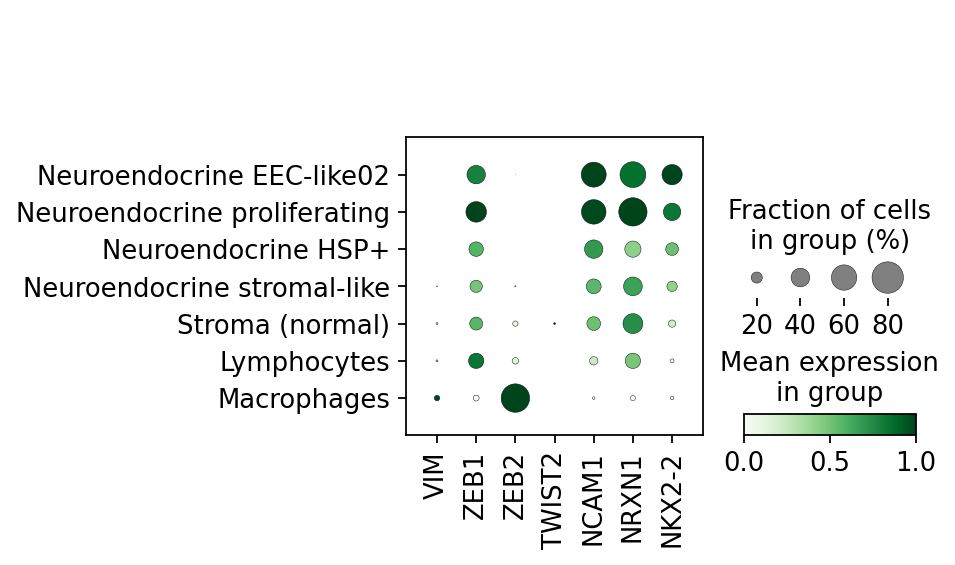

P021


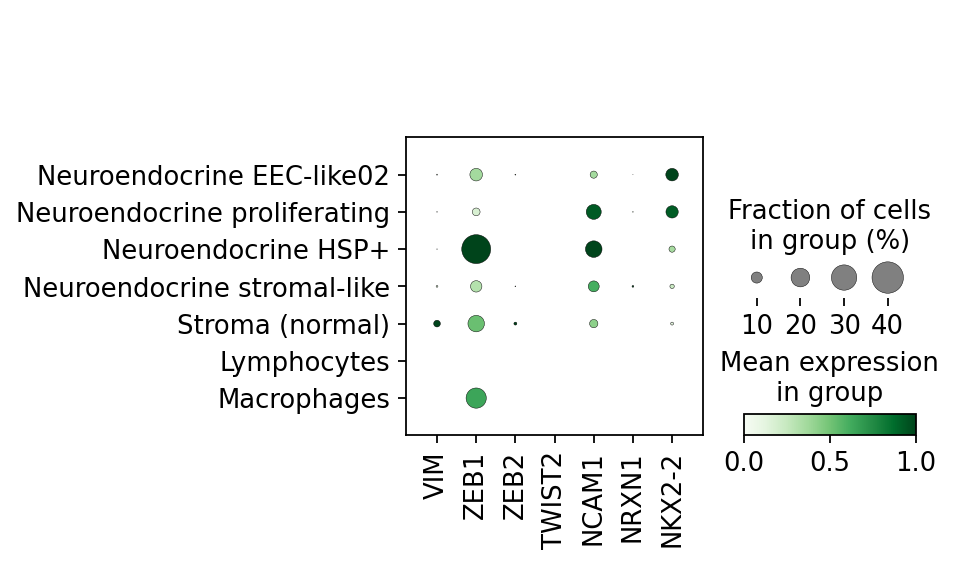

P024 (acinar-like)


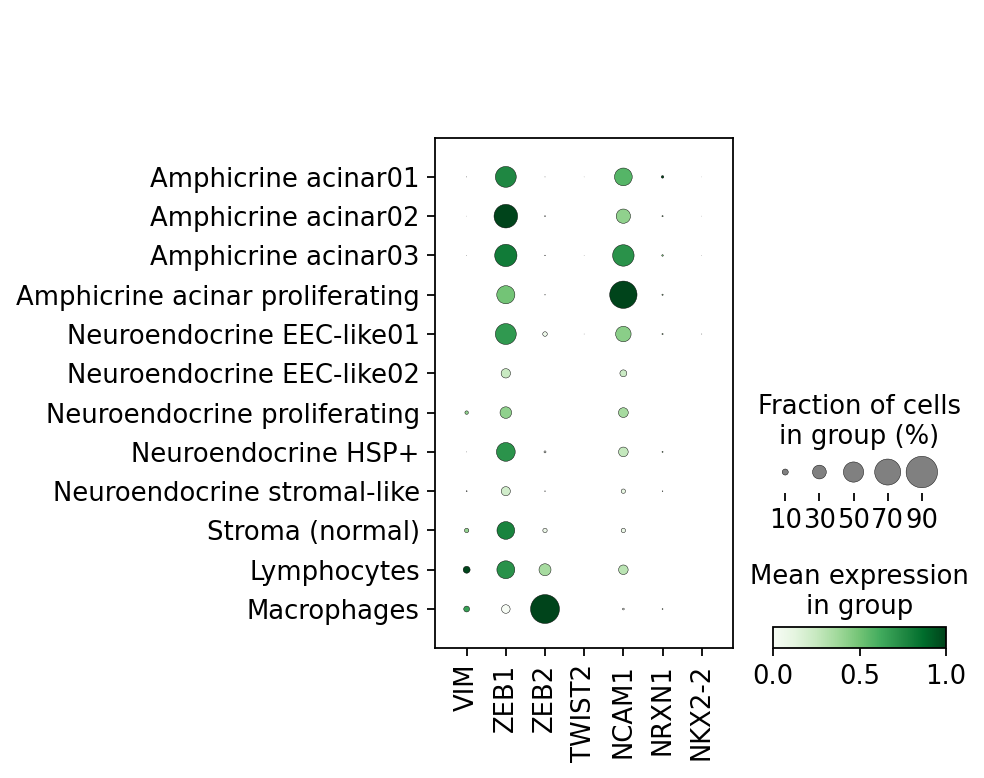

In [28]:
#Plot mesenchymal genes per patient:
for i in adata_norm.obs['PatientID'].cat.categories:
    print(i) 
    sc.pl.dotplot(adata_norm[adata_norm.obs['PatientID'] == i], 
                ['VIM', 'ZEB1', 'ZEB2', 'TWIST2', 'NCAM1', 'NRXN1', 'NKX2-2'], 
                groupby= 'Cell states', 
              swap_axes=False, dendrogram=False, 
             cmap= "Greens", standard_scale= "var")

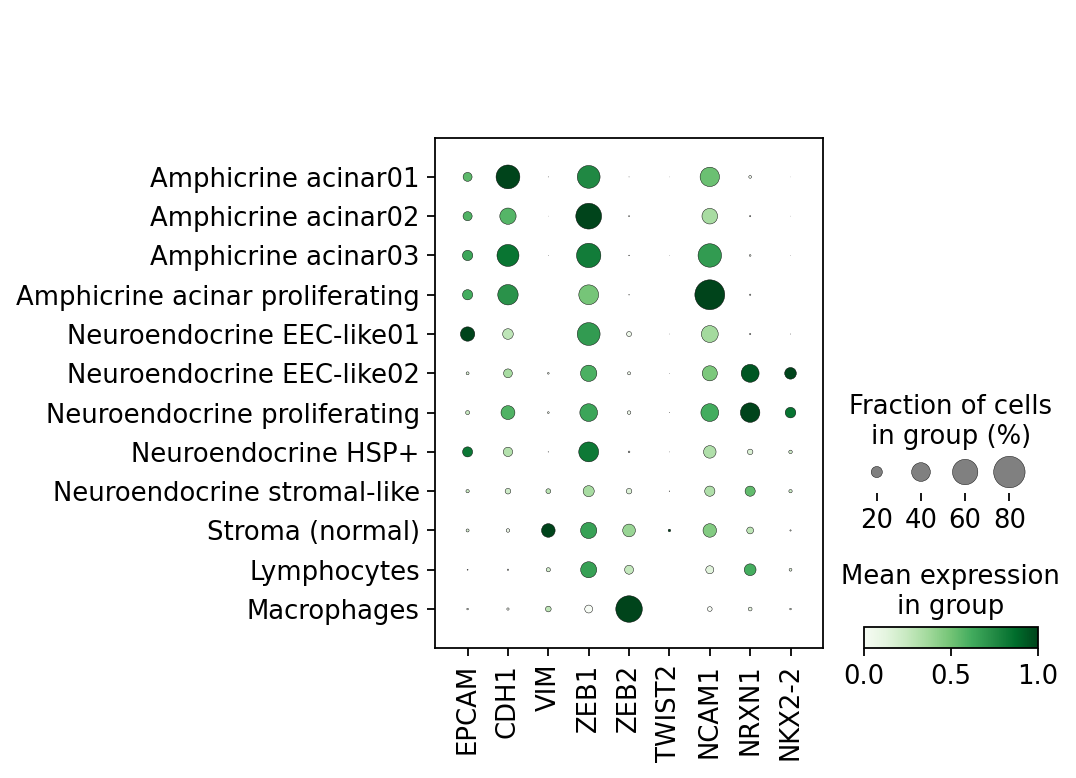

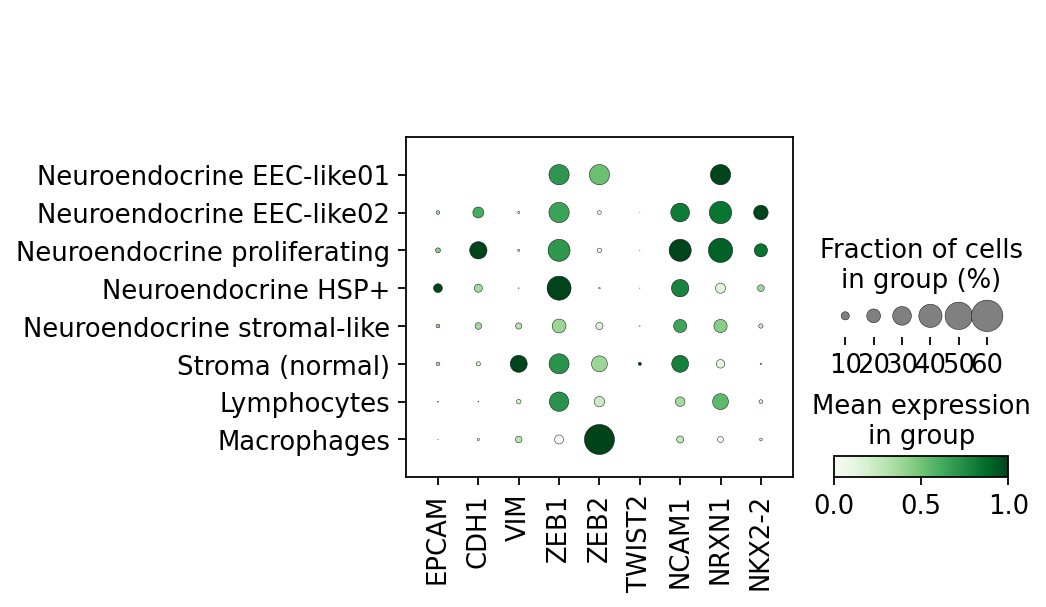

In [29]:
#Plot Epi/mesenchymal with NE genes together:
#ZEB1 can be expressed in NE cells too?! 
sc.pl.dotplot(adata_norm,  ['EPCAM', 'CDH1', 'VIM', 'ZEB1', 'ZEB2', 'TWIST2', 'NCAM1', 'NRXN1', 'NKX2-2'], 
                groupby= 'Cell states', swap_axes=False, dendrogram=False, cmap= "Greens", standard_scale="var")

#Exclude P024: 
sc.pl.dotplot(adata_norm[adata_norm.obs['PatientID']!= 'P024 (acinar-like)'],  
              ['EPCAM', 'CDH1', 'VIM', 'ZEB1', 'ZEB2', 'TWIST2', 'NCAM1', 'NRXN1', 'NKX2-2'], 
                groupby= 'Cell states', swap_axes=False, dendrogram=False, cmap= "Greens", standard_scale="var")

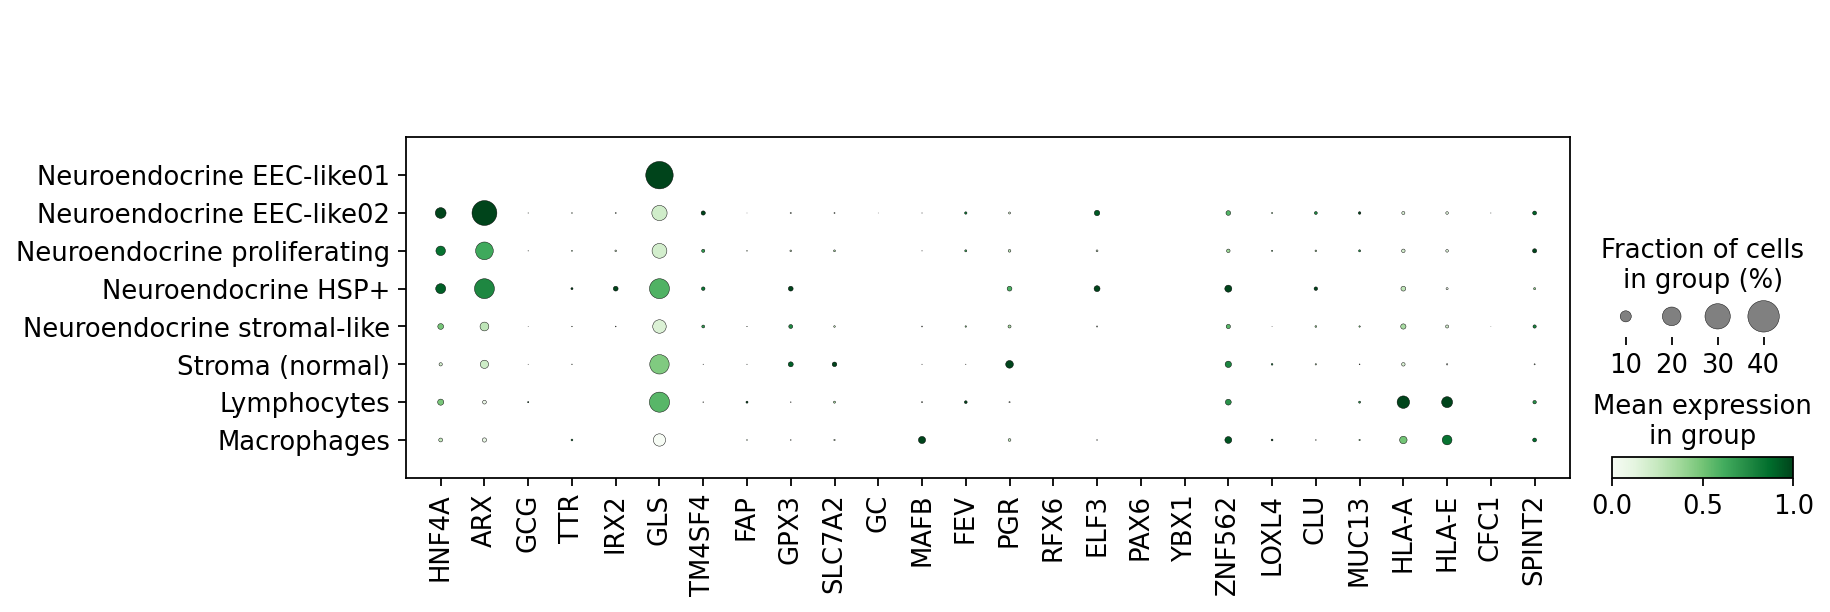

In [30]:
#Plot alpha-lineage genes: 
sc.pl.dotplot(adata_norm[adata_norm.obs['PatientID'] == 'P07'], 
              ['HNF4A', 'ARX', 'GCG', 'TTR', 'IRX2', 'GLS', 'TM4SF4', 'FAP', 'GPX3', 'SLC7A2', 'GC', 
                'MAFB', 'FEV', 'PGR', 'RFX6', 'ELF3', 'PAX6', 'YBX1', 'ZNF562',
                'LOXL4', 'CLU', 'MUC13', 'HLA-A', 'HLA-E', 'CFC1', 'SPINT2'], 
              groupby= 'Cell states', 
              swap_axes=False, dendrogram=False, 
             cmap= "Greens", standard_scale= "var")

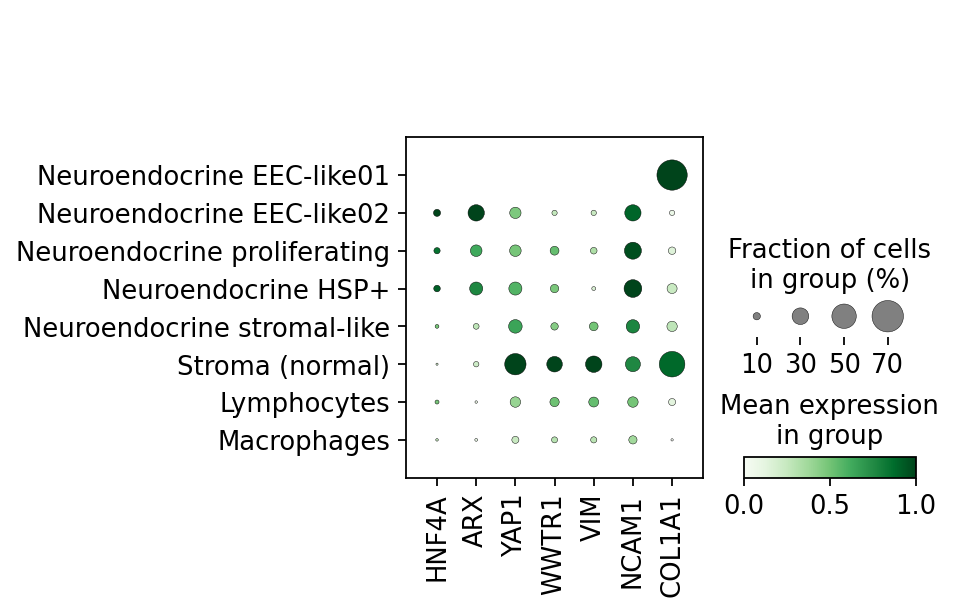

In [31]:
#ARX is robust & specific to P07: 
sc.pl.dotplot(adata_norm[adata_norm.obs['PatientID'] == 'P07'], 
              ['HNF4A', 'ARX', 'YAP1', 'WWTR1', 'VIM', 'NCAM1', 'COL1A1'], 
              groupby= 'Cell states', 
              swap_axes=False, dendrogram=False, 
             cmap= "Greens", standard_scale= "var")
#ARX is coming from ovarian stroma or not?
#Co-exp of HNF4A & ARX. 

In [32]:
#Read the signatures from Broad's PDAC paper (malignant cell state vs lineage programs)
pdac_regev= pd.read_csv("./pNET_comparative_clustering/PDAC_Regev_signatures.csv")
pdac_regev.head()

,Cycling (S),Cycling (G2/M),MYC signaling,Adhesive,Ribosomal,Interferon signaling,TNF-NFkB signaling,Acinar-like,Classical-like,Basaloid,...,NPC,fetal replicating,fetal quiescent,Oligodendrocyte precursors,Neurons,Astrocytes,Oligodendrocytes,Microglia,Highly-expressed in RB1-loss:,Low-expressed in RB1-loss:
0,HELLS,ASPM,PVT1,LAMB3,RPS17,POU6F2,LAMC2,SYCN,PTH2R,IGF2,...,RPS4Y1,LINC01158,STMN2,TNR,RTN1,AQP4,CREB5,HLA-DRA,RIBC2,RB1
1,BRIP1,CENPE,WDR43,CD55,RPS15A,HECW2,CDH2,CLPS,SULT1C2,CST6,...,TMSB15A,TFAP2C,DCX,PMP2,SNAP25,ETNPPL,APOD,RGS1,SH3GL2,KPNA3
2,DTL,TOP2A,CMSS1,EMP1,RPS23,BCAT1,ZNF365,AMY2A,ANXA10,CRYAB,...,VIM,POU3F3,NEUROD6,LUZP2,SCG2,SLC1A2,PLP1,GPR34,IQCC,COG3
3,ATAD2,KIF14,PUM3,SGMS2,RPS13,IGSF1,PODXL,PLA2G1B,HEPH,CST4,...,CCDC167,SYNE2,SOX4,PDGFRA,SYNPR,SPARCL1,ERMN,SPP1,MESP1,WBP4
4,FANCI,PIF1,LRPPRC,GPRC5D,RPL32,SOX5,COL22A1,CTRB2,WDR72,FBXO2,...,GNG5,TNC,BCL11A,RAB31,MEG3,F3,TMEM144,CCL4,CAMK2N2,SUCLA2


In [33]:
#Remove the immune cells: 
adata_norm02= adata_norm[~adata_norm.obs['cell_states'].isin(['Lymphocytes (non-tumor)', 'Macrophages (non-tumor)'])] 
print(adata_norm02.obs['cell_states'].cat.categories)

Index(['Amphicrine01 NE', 'Amphicrine02 NE', 'Amphicrine03 NE',
       'BRCA1/FANCA NEp', 'BRCA1/FANCA NEp (amphicrine)',
       'GIPR-high EEC-like NE', 'HSP+ NE', 'Stromal (mixed)', 'Stromal1',
       'WNT-high EEC-like NE'],
      dtype='object')


In [34]:
#Use top-50 features to score each signature module:
for i in pdac_regev.columns:
    pdac_sig= pdac_regev[i].values.tolist() #save column as list
    pdac_sig= pdac_sig[0:50]
    sc.tl.score_genes(adata_norm02, pdac_sig, score_name=[i])

Trying to set attribute `.obs` of view, copying.


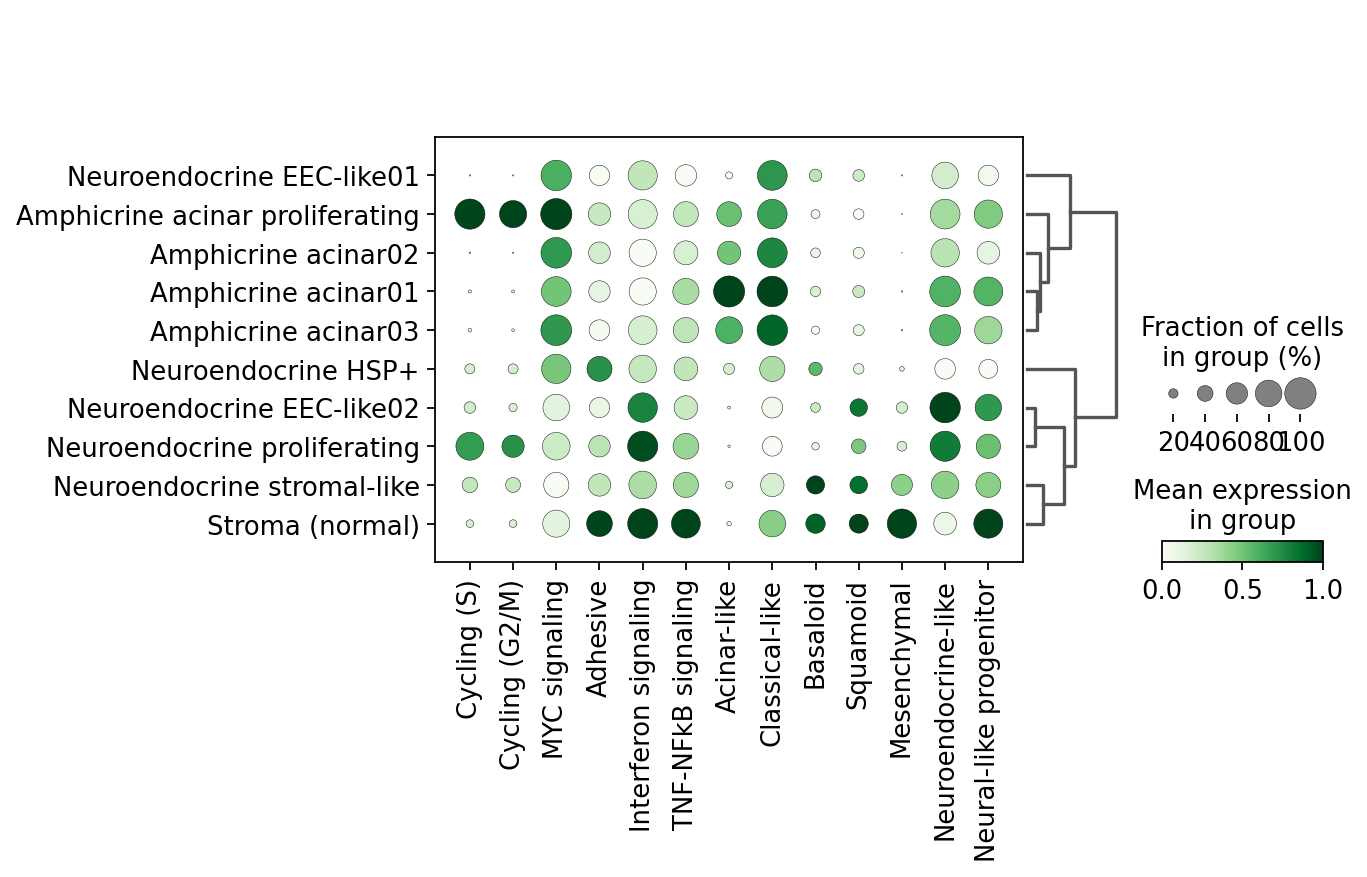

In [35]:
#Cell-states vs lineage programs:
sc.tl.dendrogram(adata_norm02, groupby= "Cell states")

sc.pl.dotplot(adata_norm02, ['Cycling (S)', 'Cycling (G2/M)', 'MYC signaling', 'Adhesive', 'Interferon signaling', 'TNF-NFkB signaling',
                           'Acinar-like', 'Classical-like', 'Basaloid', 'Squamoid', 'Mesenchymal', 
                          'Neuroendocrine-like', 'Neural-like progenitor'], 
                          groupby= "Cell states", dendrogram=True, standard_scale="var", cmap= "Greens")